# U07 — Segmentacion de usuarios por compromiso (RFM: Recencia, Frecuencia, Valor educativo)

**Escenario:** segmentar a los usuarios de la plataforma segun su nivel de
compromiso usando el enfoque **RFM** clasico de analitica, adaptado a un contexto
educativo:

- **Recencia** (`recency_days`): dias desde la ultima actividad (menor = mejor).
- **Frecuencia** (`frequency_sessions`): numero de sesiones registradas (mayor = mejor).
- **Valor educativo** (`educational_value_xp`): XP total acumulado, que aqui
  reemplaza al clasico "Monetary" de RFM — en una plataforma educativa el "valor"
  que un usuario genera/recibe no es dinero sino aprendizaje logrado, aproximado por
  el XP total.

El dataset incluye tambien `engagement_segment`, una etiqueta **latente que el propio
simulador uso para generar los datos** (casual / regular / dedicado). Esta columna se
usa **unicamente como referencia externa** para interpretar y validar los clusters
obtenidos — **nunca como feature de clustering** — porque en un escenario real esa
etiqueta no existiria (es justamente lo que queremos descubrir).


In [1]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# nbconvert ejecuta el kernel con cwd = carpeta del notebook (notebooks/unsupervised);
# nos posicionamos en la raiz del repo para que las rutas relativas ("data/...", "models/...") funcionen.
if (Path.cwd() / "data").exists() is False and (Path.cwd().parents[1] / "data").exists():
    os.chdir(Path.cwd().parents[1])
print("cwd:", Path.cwd())

sns.set_theme(style="whitegrid")
RANDOM_STATE = 2026

rfm = pd.read_csv("data/processed/user_rfm.csv")
print(rfm.shape)
rfm.head()


cwd: C:\Users\tass1\Videos\tutunakun\tutunakun
(800, 7)


,user_id,engagement_segment,region,device_type,recency_days,frequency_sessions,educational_value_xp
0,1,casual,semiurbano,desktop,10,12,416.0
1,2,regular,rural,mobile,0,9,3513.0
2,3,casual,urbano,mobile,6,6,583.0
3,4,casual,rural,mobile,11,5,481.0
4,5,casual,rural,mobile,23,3,405.0


In [2]:
feature_cols = ["recency_days", "frequency_sessions", "educational_value_xp"]
rfm[feature_cols + ["engagement_segment"]].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recency_days,800.0,NaN,NaN,NaN,2.5975,3.811319,0.0,0.0,1.0,4.0,29.0
frequency_sessions,800.0,NaN,NaN,NaN,10.0,5.035046,1.0,6.0,9.0,13.0,27.0
educational_value_xp,800.0,NaN,NaN,NaN,1636.98375,1258.738486,208.0,650.5,1313.0,2296.25,7279.0
engagement_segment,800,3,casual,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Exploracion de datos (EDA)

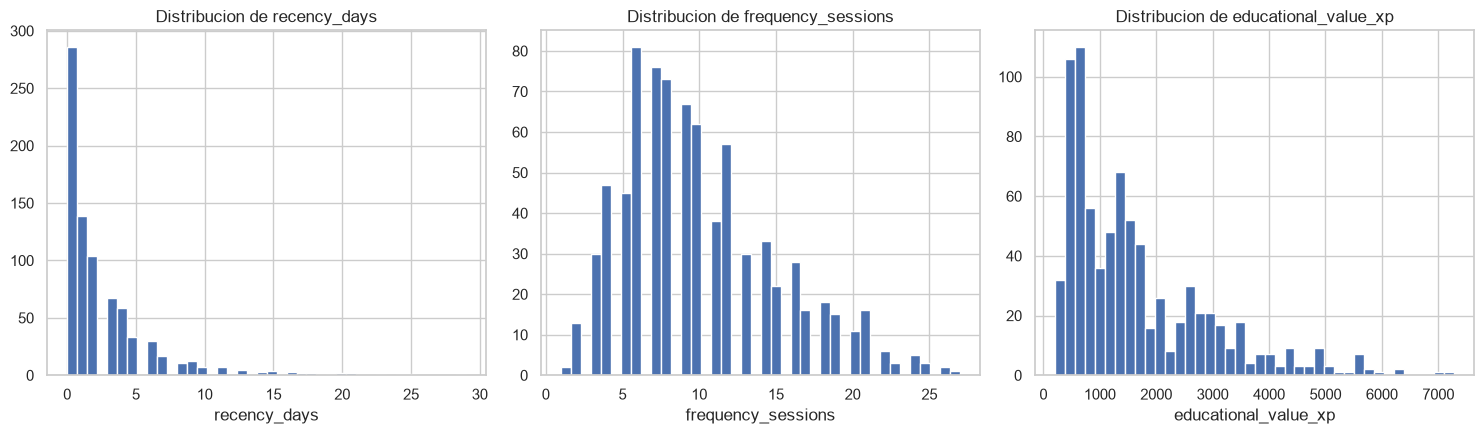

recency_days            2.789953
frequency_sessions      0.805918
educational_value_xp    1.426305
dtype: float64

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, feature_cols):
    ax.hist(rfm[col], bins=40, color="#4C72B0")
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

rfm[feature_cols].skew()


**Interpretacion:** las tres variables muestran asimetria positiva (cola a la
derecha): la mayoria de los usuarios tiene recencia baja / frecuencia moderada / XP
moderado, pero hay una minoria con valores mucho mas altos (usuarios muy
comprometidos) o de recencia muy alta (usuarios inactivos hace semanas). Esta
asimetria es tipica de metricas de comportamiento y refuerza la necesidad de escalar
antes de aplicar un algoritmo basado en distancias como K-Means.

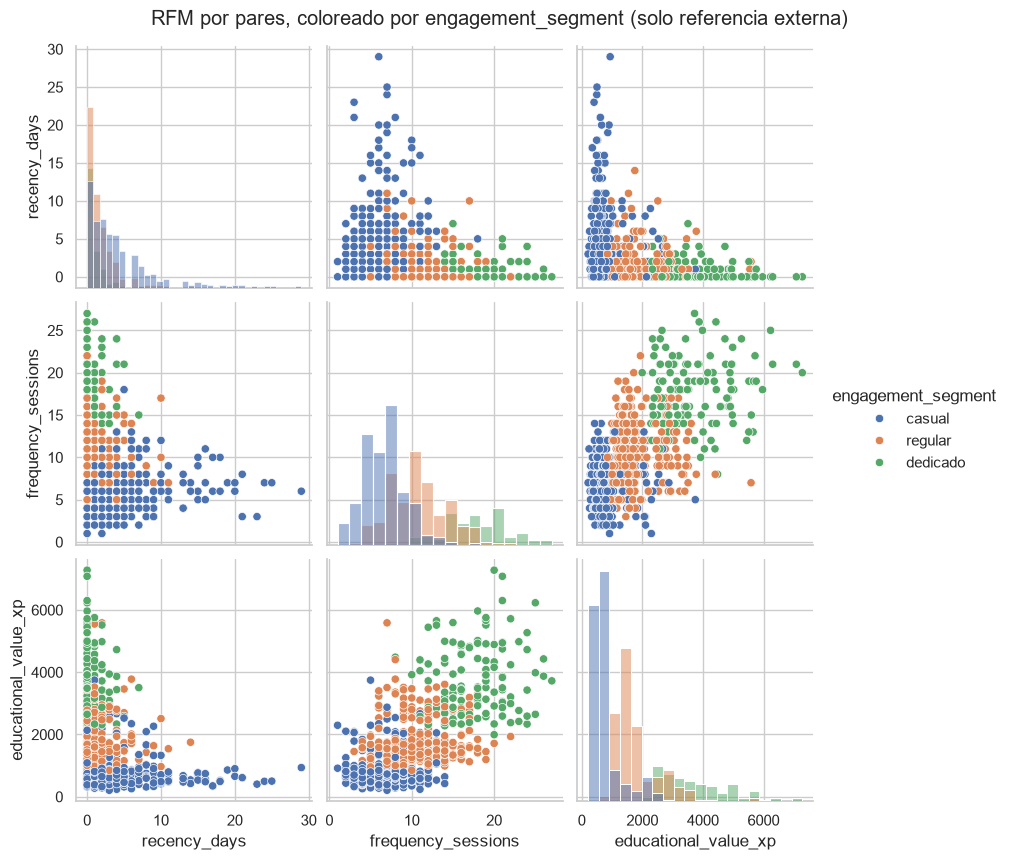

In [4]:
sns.pairplot(rfm, vars=feature_cols, hue="engagement_segment",
             palette={"casual": "#4C72B0", "regular": "#DD8452", "dedicado": "#55A868"},
             diag_kind="hist", height=2.8)
plt.suptitle("RFM por pares, coloreado por engagement_segment (solo referencia externa)", y=1.02)
plt.show()


**Nota:** el color por `engagement_segment` se muestra unicamente como
referencia visual externa (sabemos que el simulador la genero de forma latente); el
modelo de clustering que construimos mas abajo **no ve esta columna**.

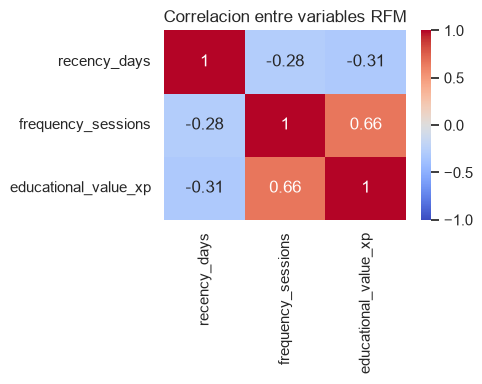

,recency_days,frequency_sessions,educational_value_xp
recency_days,1.000000,-0.280507,-0.312025
frequency_sessions,-0.280507,1.000000,0.662975
educational_value_xp,-0.312025,0.662975,1.000000


In [5]:
corr = rfm[feature_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlacion entre variables RFM")
plt.tight_layout()
plt.show()
corr


## 2. Preprocesamiento: por que escalar es obligatorio para K-Means

`recency_days` (rango ~0-29), `frequency_sessions` (~1-27) y `educational_value_xp`
(~200-7000+) tienen escalas muy distintas. K-Means (y jerarquico con distancia
euclidiana) calcula distancias entre puntos: sin escalar, `educational_value_xp`
dominaria completamente la metrica de distancia solo por tener valores numericamente
mas grandes, distorsionando los clusters (esto es exactamente la advertencia que hace
la guia del proyecto sobre no usar K-Means sin escalar). Por eso aplicamos
`StandardScaler` (media 0, desvio 1) a las 3 variables antes de agrupar.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[feature_cols])
X_scaled[:5]


array([[ 1.94345611,  0.39746432, -0.97061272],
       [-0.68194897, -0.19873216,  1.49132634],
       [ 0.89329408, -0.79492863, -0.8378572 ],
       [ 2.20599661, -0.99366079, -0.91894141],
       [ 5.3564827 , -1.39112511, -0.97935709]])

## 3. Seleccion de k para K-Means (codo + silhouette)

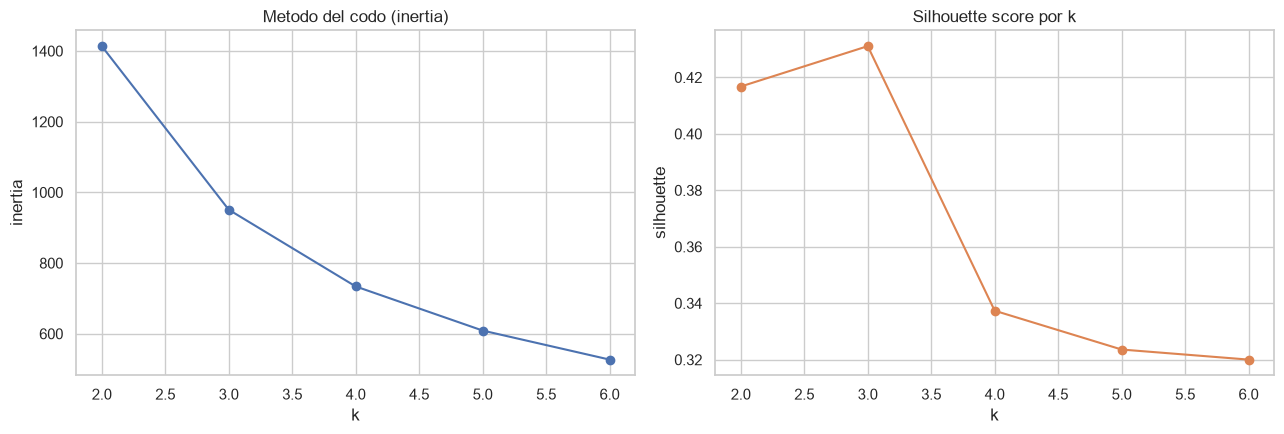

,inertia,silhouette
2,1413.777874,0.416751
3,950.924408,0.431056
4,733.807548,0.337341
5,608.955722,0.323594
6,526.775319,0.320029


In [7]:
inertias = {}
silhouettes = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(X_scaled, labels_k)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker="o", color="#4C72B0")
axes[0].set_title("Metodo del codo (inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")

axes[1].plot(list(silhouettes.keys()), list(silhouettes.values()), marker="o", color="#DD8452")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

pd.DataFrame({"inertia": inertias, "silhouette": silhouettes})


In [8]:
best_k = max(silhouettes, key=silhouettes.get)
print("k elegido (mejor silhouette):", best_k)


k elegido (mejor silhouette): 3


**Justificacion de k:** se elige el `k` con mayor silhouette score entre 2 y 6,
usando el metodo del codo como apoyo visual (donde la caida de inertia se vuelve
menos pronunciada). El valor exacto elegido se imprime arriba y se usa consistentemente
en el resto del notebook.

## 4. Comparacion K-Means vs Clustering Jerarquico (mismo k)

In [9]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

agglo_final = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agglo_labels = agglo_final.fit_predict(X_scaled)

comparison = pd.DataFrame({
    "algorithm": ["KMeans", "AgglomerativeClustering"],
    "silhouette": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, agglo_labels),
    ],
    "davies_bouldin": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, agglo_labels),
    ],
    "inertia": [kmeans_final.inertia_, np.nan],
})
comparison


,algorithm,silhouette,davies_bouldin,inertia
0,KMeans,0.431056,0.829546,950.924408
1,AgglomerativeClustering,0.444240,0.705708,NaN


**Decision del modelo ganador:** se compara silhouette (mas alto = mejor,
clusters mas separados/compactos) y Davies-Bouldin (mas bajo = mejor, menor
solapamiento entre clusters). Independientemente de cual algoritmo gane en estas
metricas, **el artefacto exportado para servir la API sera K-Means**, ya que
`AgglomerativeClustering` de scikit-learn no implementa `.predict()` para asignar
NUEVOS usuarios a un cluster ya entrenado (solo puede recalcular el clustering
completo con `.fit_predict()` sobre todos los puntos a la vez). K-Means si soporta
`.predict()` sobre datos nuevos, lo cual es indispensable para un servicio que debe
clasificar usuarios que se registran despues del entrenamiento. Si en el futuro se
requiere la calidad marginal extra del clustering jerarquico, se podria re-entrenar
periodicamente en batch y cachear las asignaciones.

## 5. Interpretacion de los clusters de K-Means

In [10]:
rfm_labeled = rfm.copy()
rfm_labeled["cluster"] = kmeans_labels

# Centroides en escala original (inverse_transform)
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroids_df.index.name = "cluster"
centroids_df["n_users"] = rfm_labeled["cluster"].value_counts().sort_index().values
centroids_df


,recency_days,frequency_sessions,educational_value_xp,n_users
cluster,,,,
0,0.917476,16.383495,3291.077670,206
1,1.871845,7.994175,1110.518447,515
2,11.708861,6.430380,755.797468,79


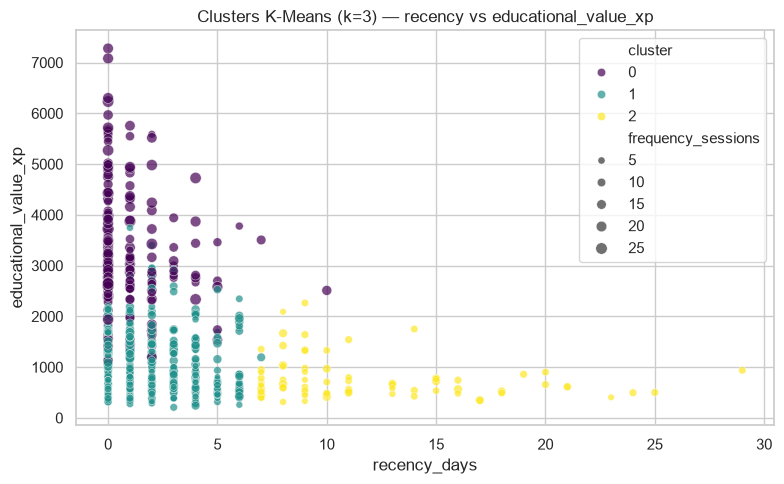

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=rfm_labeled, x="recency_days", y="educational_value_xp",
                 hue="cluster", size="frequency_sessions", palette="viridis", ax=ax, alpha=0.7)
ax.set_title(f"Clusters K-Means (k={best_k}) — recency vs educational_value_xp")
plt.tight_layout()
plt.show()


In [12]:
cluster_profiles = {}
for cluster_id, row in centroids_df.iterrows():
    cluster_profiles[str(cluster_id)] = (
        f"recency_days~{row['recency_days']:.1f}, "
        f"frequency_sessions~{row['frequency_sessions']:.1f}, "
        f"educational_value_xp~{row['educational_value_xp']:.0f} "
        f"(n={int(row['n_users'])})"
    )

for cid, desc in cluster_profiles.items():
    print(f"Cluster {cid}: {desc}")


Cluster 0: recency_days~0.9, frequency_sessions~16.4, educational_value_xp~3291 (n=206)
Cluster 1: recency_days~1.9, frequency_sessions~8.0, educational_value_xp~1111 (n=515)
Cluster 2: recency_days~11.7, frequency_sessions~6.4, educational_value_xp~756 (n=79)


**Interpretacion (usar los valores concretos de `centroids_df` de arriba para
completar la lectura):** el cluster con menor `recency_days`, mayor
`frequency_sessions` y mayor `educational_value_xp` corresponde a usuarios altamente
comprometidos (activos recientemente, entran seguido, acumulan mucho XP). En el
extremo opuesto, el cluster con `recency_days` alto y valores bajos de frecuencia/XP
corresponde a usuarios en riesgo de abandono o ya inactivos. Los clusters intermedios
representan usuarios "regulares" con compromiso moderado. Las etiquetas concretas por
cluster (con las cifras reales obtenidas) se guardan en `cluster_profiles` y se
exportan en el metadata para uso en dashboards.

In [13]:
crosstab = pd.crosstab(rfm_labeled["cluster"], rfm_labeled["engagement_segment"])
crosstab


engagement_segment,casual,dedicado,regular
cluster,,,
0,2,132,72
1,292,0,223
2,72,0,7


**Validacion externa (no usada para entrenar):** el cruce contra
`engagement_segment` (la etiqueta latente del simulador) permite verificar que los
clusters obtenidos de forma no supervisada recuperan razonablemente la segmentacion
real subyacente (p. ej. el cluster de mayor compromiso deberia concentrar la mayoria
de los usuarios `dedicado`). Esto es una validacion de sanity-check, no una senal de
entrenamiento.

## 6. Metricas finales del modelo elegido (K-Means)

In [14]:
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
final_db = davies_bouldin_score(X_scaled, kmeans_labels)
final_inertia = kmeans_final.inertia_
print(f"k = {best_k}")
print(f"Silhouette = {final_silhouette:.4f}")
print(f"Davies-Bouldin = {final_db:.4f}")
print(f"Inertia = {final_inertia:.2f}")


k = 3
Silhouette = 0.4311
Davies-Bouldin = 0.8295
Inertia = 950.92


## 7. Exportacion del artefacto

In [15]:
import os
os.makedirs("models/serialized", exist_ok=True)

export_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)),
])
export_pipeline.fit(rfm[feature_cols])

joblib.dump({"pipeline": export_pipeline}, "models/serialized/rfm_kmeans.joblib")

metadata = {
    "model_name": "rfm_kmeans",
    "version": "1.0.0",
    "algorithm": "kmeans",
    "task": "clustering",
    "features": feature_cols,
    "k": int(best_k),
    "cluster_profiles": cluster_profiles,
    "metrics": {
        "silhouette": float(final_silhouette),
        "davies_bouldin": float(final_db),
        "inertia": float(final_inertia),
    },
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "notes": (
        "Pipeline = StandardScaler + KMeans, entrenado sobre las 3 variables RFM "
        "(recency_days, frequency_sessions, educational_value_xp). Se eligio KMeans "
        "sobre AgglomerativeClustering porque el servicio debe poder llamar "
        ".predict() sobre usuarios NUEVOS via API, algo que AgglomerativeClustering "
        "no soporta nativamente (comparacion de calidad entre ambos esta en la seccion "
        "4 del notebook: silhouette y Davies-Bouldin). engagement_segment (etiqueta "
        "latente del simulador) se uso solo como validacion externa via crosstab, "
        "nunca como feature de entrenamiento."
    ),
}
with open("models/serialized/rfm_kmeans_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(json.dumps(metadata, indent=2, ensure_ascii=False))


{
  "model_name": "rfm_kmeans",
  "version": "1.0.0",
  "algorithm": "kmeans",
  "task": "clustering",
  "features": [
    "recency_days",
    "frequency_sessions",
    "educational_value_xp"
  ],
  "k": 3,
  "cluster_profiles": {
    "0": "recency_days~0.9, frequency_sessions~16.4, educational_value_xp~3291 (n=206)",
    "1": "recency_days~1.9, frequency_sessions~8.0, educational_value_xp~1111 (n=515)",
    "2": "recency_days~11.7, frequency_sessions~6.4, educational_value_xp~756 (n=79)"
  },
  "metrics": {
    "silhouette": 0.4310555842370513,
    "davies_bouldin": 0.8295463203460799,
    "inertia": 950.9244075151862
  },
  "trained_at": "2026-08-01T01:08:29.808216+00:00",
  "notes": "Pipeline = StandardScaler + KMeans, entrenado sobre las 3 variables RFM (recency_days, frequency_sessions, educational_value_xp). Se eligio KMeans sobre AgglomerativeClustering porque el servicio debe poder llamar .predict() sobre usuarios NUEVOS via API, algo que AgglomerativeClustering no soporta nati

## 8. Verificacion final: recargar el artefacto y predecir el cluster de usuarios sinteticos

In [16]:
loaded = joblib.load("models/serialized/rfm_kmeans.joblib")
loaded_pipeline = loaded["pipeline"]

with open("models/serialized/rfm_kmeans_metadata.json", "r", encoding="utf-8") as f:
    loaded_metadata = json.load(f)

synthetic_users = pd.DataFrame({
    "recency_days": [0, 28, 3],
    "frequency_sessions": [25, 1, 9],
    "educational_value_xp": [6800.0, 250.0, 1400.0],
}, index=["reciente_frecuente_alto_xp", "ausente_bajo_xp", "usuario_promedio"])

pred_clusters = loaded_pipeline.predict(synthetic_users[feature_cols])

for name, cluster_id in zip(synthetic_users.index, pred_clusters):
    profile = loaded_metadata["cluster_profiles"].get(str(cluster_id), "sin perfil")
    print(f"{name} -> cluster {cluster_id}: {profile}")


reciente_frecuente_alto_xp -> cluster 0: recency_days~0.9, frequency_sessions~16.4, educational_value_xp~3291 (n=206)
ausente_bajo_xp -> cluster 2: recency_days~11.7, frequency_sessions~6.4, educational_value_xp~756 (n=79)
usuario_promedio -> cluster 1: recency_days~1.9, frequency_sessions~8.0, educational_value_xp~1111 (n=515)
